# ROI Explorer — March 27 RGB dataset
Loads SR outputs for one combo and helps identify crop regions for evaluation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from PIL import Image
from scipy.ndimage import gaussian_filter1d

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120})

## 1. Load one combo's SR outputs

In [2]:
import os

# ── Change these to explore different combos ──────────────────────────────────
SESSION   = '20260327_125058'
COMBO     = 'special_1.0px_settle20ms'   # or e.g. 'tilt0.36000deg_settle20ms'
# ─────────────────────────────────────────────────────────────────────────────

BASE  = f'/Users/shuyu/ENPH459-Super-Resolution/imaging/sr/mar27_rgb_images'
OUT   = os.path.join(BASE, SESSION, 'results', COMBO)
RAW   = os.path.join(BASE, SESSION, COMBO)

def load(fname):
    return np.array(Image.open(os.path.join(OUT, fname)), dtype=np.float64)

lr_red  = np.array(Image.open(os.path.join(OUT, 'LR_red_mean.png')), dtype=np.float64)
native  = load('Native-2x.png')
saa     = load('SAA.png')
saa_ibp = load('SAA_IBP.png')

images = {'LR red': lr_red, 'Native-2x': native, 'SAA': saa, 'SAA+IBP': saa_ibp}

print('LR red shape:', lr_red.shape)
print('HR shape:    ', native.shape)

LR red shape: (768, 1024)
HR shape:     (1536, 2048)


## 2. Full image overview (HR, all methods)

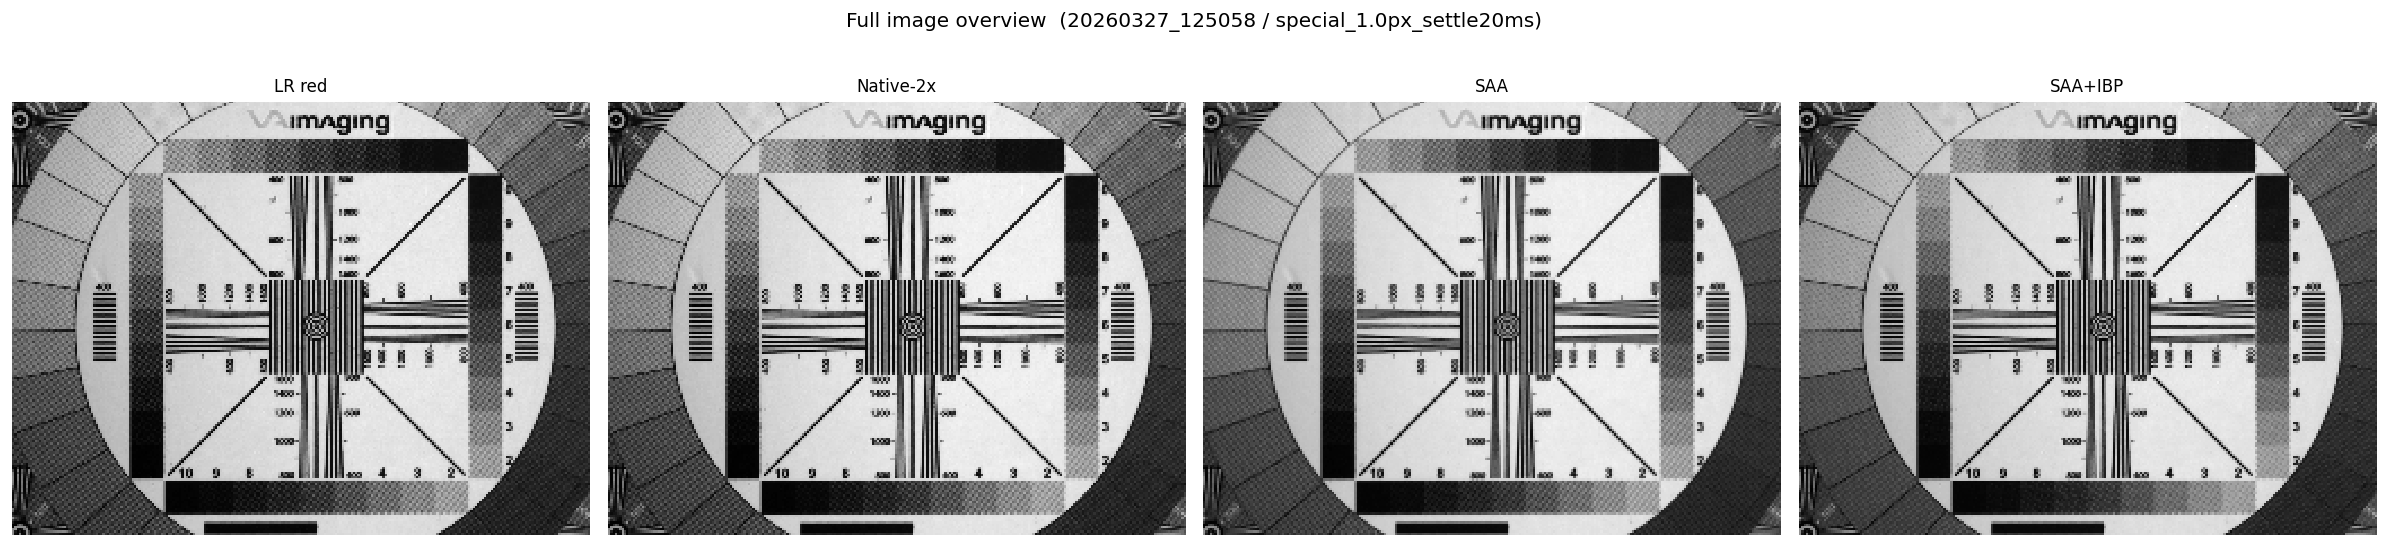

In [3]:
fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
ds = 4
for ax, (name, img) in zip(axes, images.items()):
    disp = img if name == 'LR red' else img
    step = ds * 2 if name != 'LR red' else ds
    ax.imshow(disp[::step, ::step], cmap='gray', interpolation='nearest')
    ax.set_title(name, fontsize=10)
    ax.axis('off')
plt.suptitle(f'Full image overview  ({SESSION} / {COMBO})', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Define ROIs
Edit the coordinates below, then run the cells below to check the crops.  
All coordinates are in **HR pixel space** (1536 × 2048).

In [33]:
# ── ROI definitions (row0, row1, col0, col1) in HR pixel space ───────────────
# Fill these in after looking at the overview above.

# ROI_A = (700, 750, 1500, 1600)    # TODO: adjust
ROI_B = (784, 806, 1500,  1600)    # TODO: adjust
ROI_C = (820, 860, 1500, 1600)  # TODO: adjust


ROI_A = (365, 465, 1400, 1500)  # TODO: adjust

ROIS = {
    'ROI A': ROI_A,
    'ROI B': ROI_B,
    'ROI C': ROI_C,
}
ROI_COLORS = {'ROI A': 'cyan', 'ROI B': 'lime', 'ROI C': 'yellow'}

## 4. Annotated full image (ROI boxes)

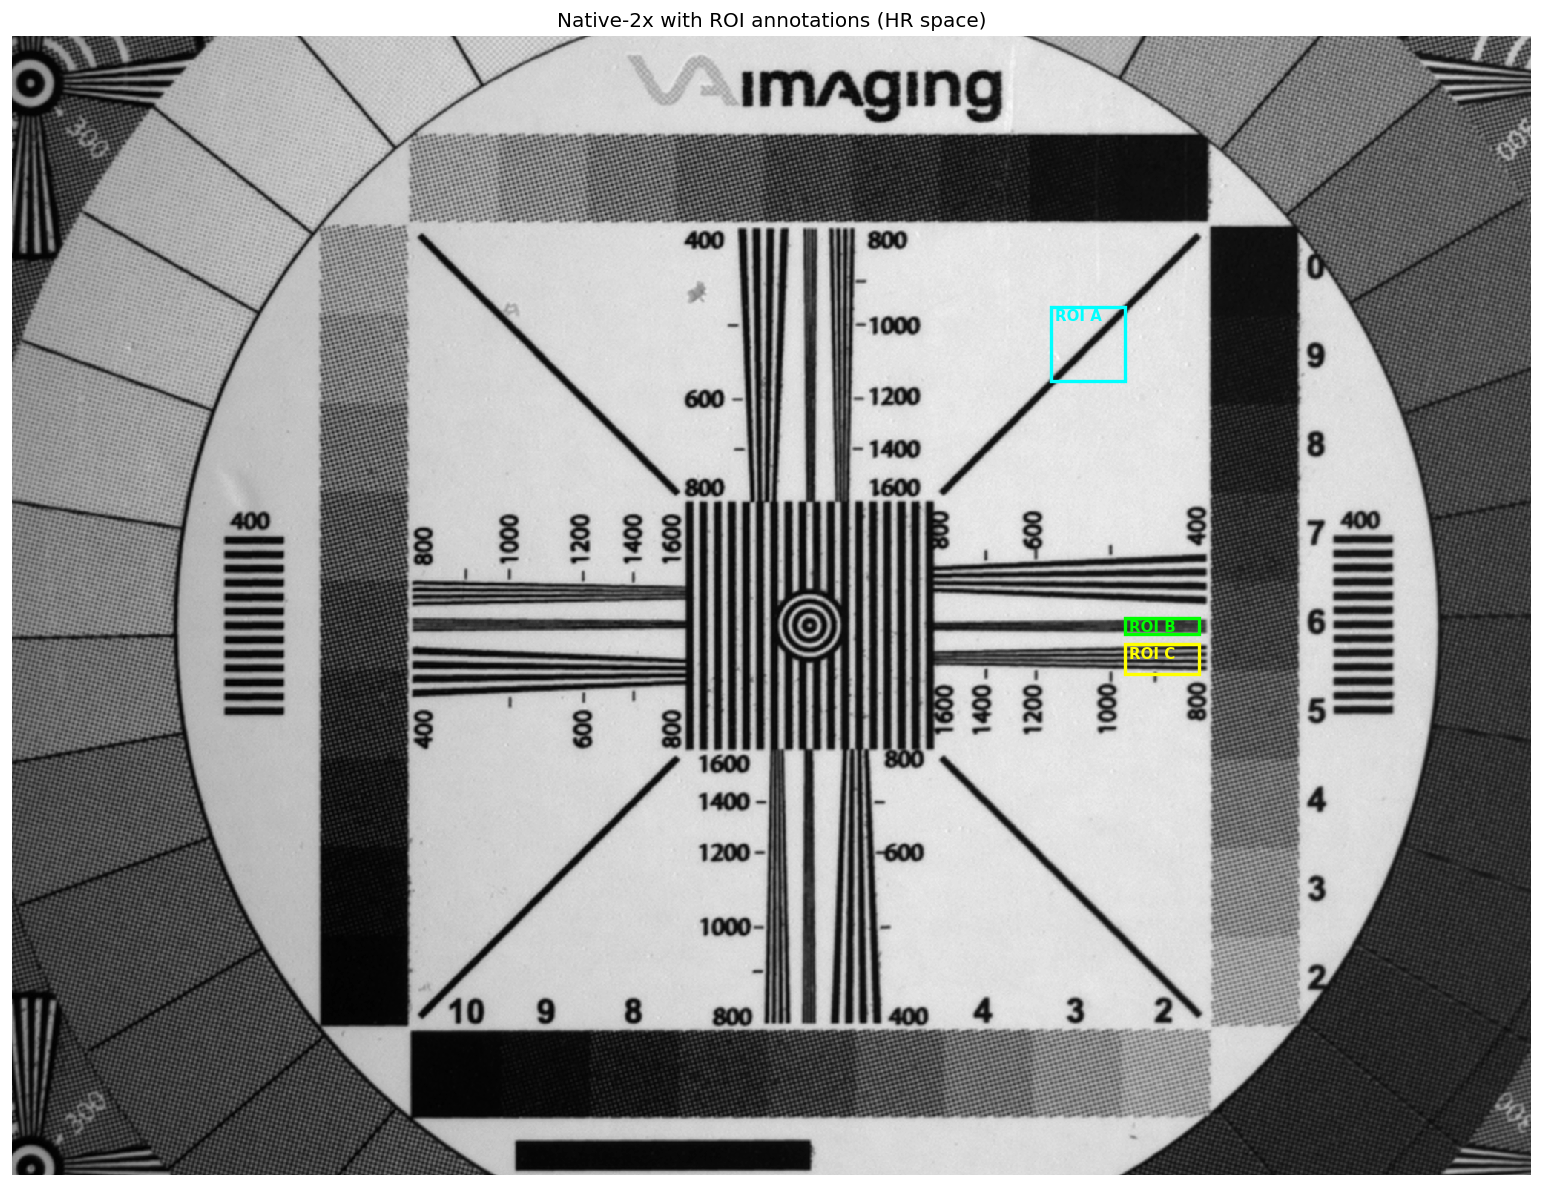

In [34]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(native, cmap='gray', interpolation='nearest')
for name, (r0, r1, c0, c1) in ROIS.items():
    rect = Rectangle((c0, r0), c1-c0, r1-r0, lw=2,
                      edgecolor=ROI_COLORS[name], facecolor='none')
    ax.add_patch(rect)
    ax.text(c0+6, r0+18, name, color=ROI_COLORS[name], fontsize=9, fontweight='bold')
ax.set_title('Native-2x with ROI annotations (HR space)', fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.show()

## 5. ROI B — zoomed comparison (matched contrast)

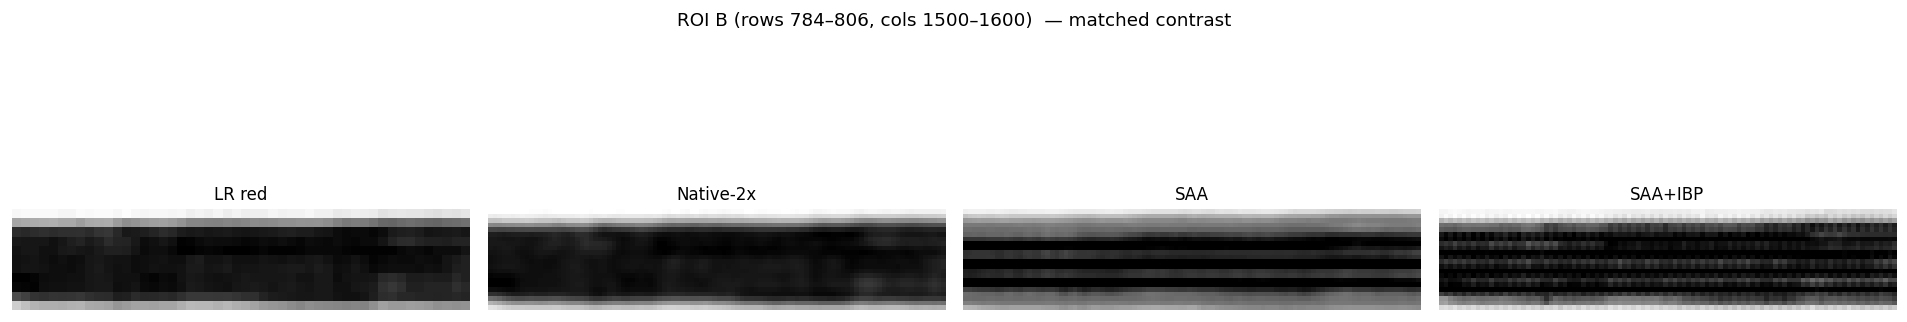

In [24]:
r0, r1, c0, c1 = ROIS['ROI B']

hr_methods = {k: v for k, v in images.items() if k != 'LR red'}
n = len(hr_methods) + 1   # +1 for LR

fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

# Shared display range from the native crop (so all panels are on the same scale)
ref_crop = images['Native-2x'][r0:r1, c0:c1]
vmin, vmax = np.percentile(ref_crop, [1, 99])

# LR reference (half-res → scale ROI)
lr_crop = images['LR red'][r0//2:r1//2, c0//2:c1//2]
axes[0].imshow(lr_crop, cmap='gray', vmin=vmin, vmax=vmax, interpolation='nearest')
axes[0].set_title('LR red', fontsize=10)
axes[0].axis('off')

for i, (name, img) in enumerate(hr_methods.items(), 1):
    axes[i].imshow(img[r0:r1, c0:c1], cmap='gray', vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[i].set_title(name, fontsize=10)
    axes[i].axis('off')

plt.suptitle(f'ROI B (rows {r0}–{r1}, cols {c0}–{c1})  — matched contrast', fontsize=11)
plt.tight_layout()
plt.show()

## 6. ROI B — vertical cross-section profile
Takes a vertical slice (one column or average of a few) through the **right portion** of ROI B where the lines are finest.  
A sharper method will show higher-amplitude oscillations between the dark lines and bright gaps.

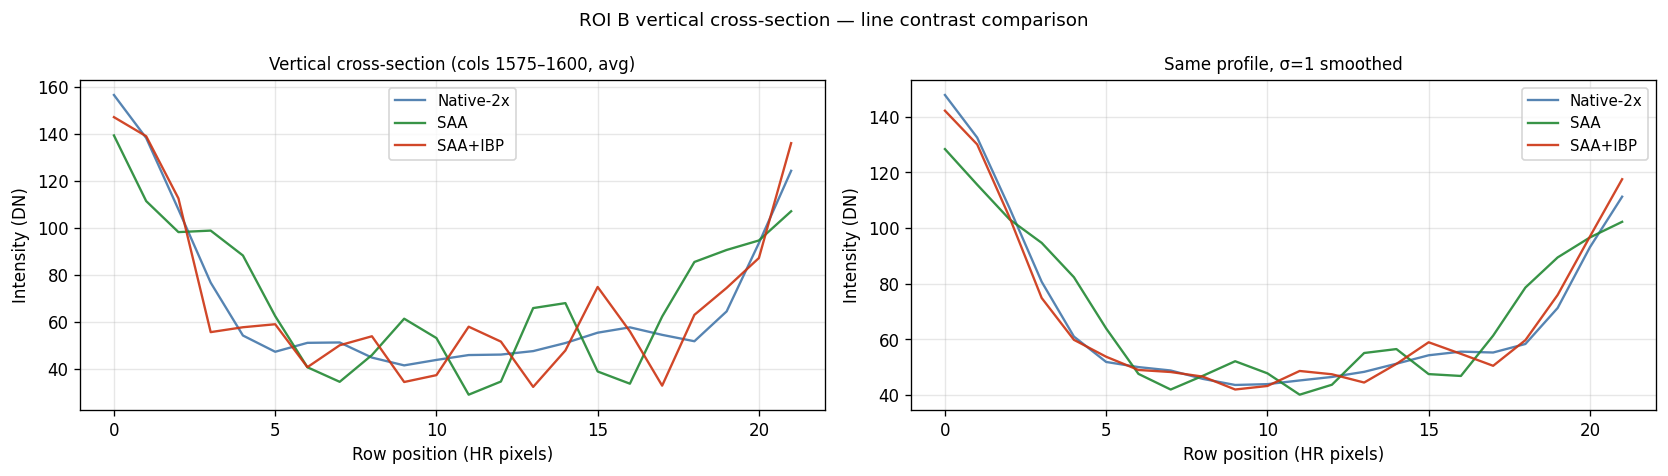


ROI B line contrast  (cols 1575–1600, σ=1 smoothed)

Method           RMS contrast   Michelson    Std (DN)   pk-pk (DN)
─────────────────────────────────────────────────────────────────
Native-2x              0.4380      0.5450       29.92       104.32
SAA                    0.3770      0.5244       26.42        88.35
SAA+IBP                0.4326      0.5447       29.48       100.30


In [25]:
r0, r1, c0, c1 = ROIS['ROI B']

# ── Column range to average over (right 25% of ROI B) ────────────────────────
width = c1 - c0
col_lo = c1 - width // 4   # right quarter
col_hi = c1
# ─────────────────────────────────────────────────────────────────────────────

METHOD_COLORS = {'Native-2x': '#4477AA', 'SAA': '#228833', 'SAA+IBP': '#CC3311'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Left panel: raw profiles ──────────────────────────────────────────────────
for name, img in images.items():
    if name not in ('Native-2x', 'SAA+IBP'):
        continue
    profile = img[r0:r1, col_lo:col_hi].mean(axis=1)
    axes[0].plot(profile, lw=1.4, label=name,
                 color=METHOD_COLORS.get(name, 'gray'), alpha=0.9)

axes[0].set_xlabel('Row position (HR pixels)', fontsize=10)
axes[0].set_ylabel('Intensity (DN)', fontsize=10)
axes[0].set_title(f'Vertical cross-section (cols {col_lo}–{col_hi}, avg)', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Right panel: lightly smoothed for clarity ─────────────────────────────────
for name, img in images.items():
    if name not in ('Native-2x', 'SAA+IBP'):
        continue
    profile = img[r0:r1, col_lo:col_hi].mean(axis=1)
    profile_s = gaussian_filter1d(profile, sigma=1.0)
    axes[1].plot(profile_s, lw=1.4, label=name,
                 color=METHOD_COLORS.get(name, 'gray'), alpha=0.9)

axes[1].set_xlabel('Row position (HR pixels)', fontsize=10)
axes[1].set_ylabel('Intensity (DN)', fontsize=10)
axes[1].set_title('Same profile, σ=1 smoothed', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('ROI B vertical cross-section — line contrast comparison', fontsize=11)
plt.tight_layout()
plt.show()

# ── Quantification ────────────────────────────────────────────────────────────
print(f'\nROI B line contrast  (cols {col_lo}–{col_hi}, σ=1 smoothed)\n')
print(f"{'Method':<14}  {'RMS contrast':>13}  {'Michelson':>10}  {'Std (DN)':>10}  {'pk-pk (DN)':>11}")
print('─' * 65)

for name, img in images.items():
    if name not in ('Native-2x', 'SAA+IBP'):
        continue
    profile   = img[r0:r1, col_lo:col_hi].mean(axis=1)
    profile_s = gaussian_filter1d(profile, sigma=1.0)
    mn, mx    = profile_s.min(), profile_s.max()
    rms       = profile_s.std() / profile_s.mean() if profile_s.mean() != 0 else 0
    michelson = (mx - mn) / (mx + mn) if (mx + mn) != 0 else 0
    std       = profile_s.std()
    pkpk      = mx - mn
    print(f'{name:<14}  {rms:>13.4f}  {michelson:>10.4f}  {std:>10.2f}  {pkpk:>11.2f}')

## 7. Compare all combos for one method on one ROI
Useful once you've run the sweep to see which tilt/settle works best.

Found 28 completed combos for SAA+IBP


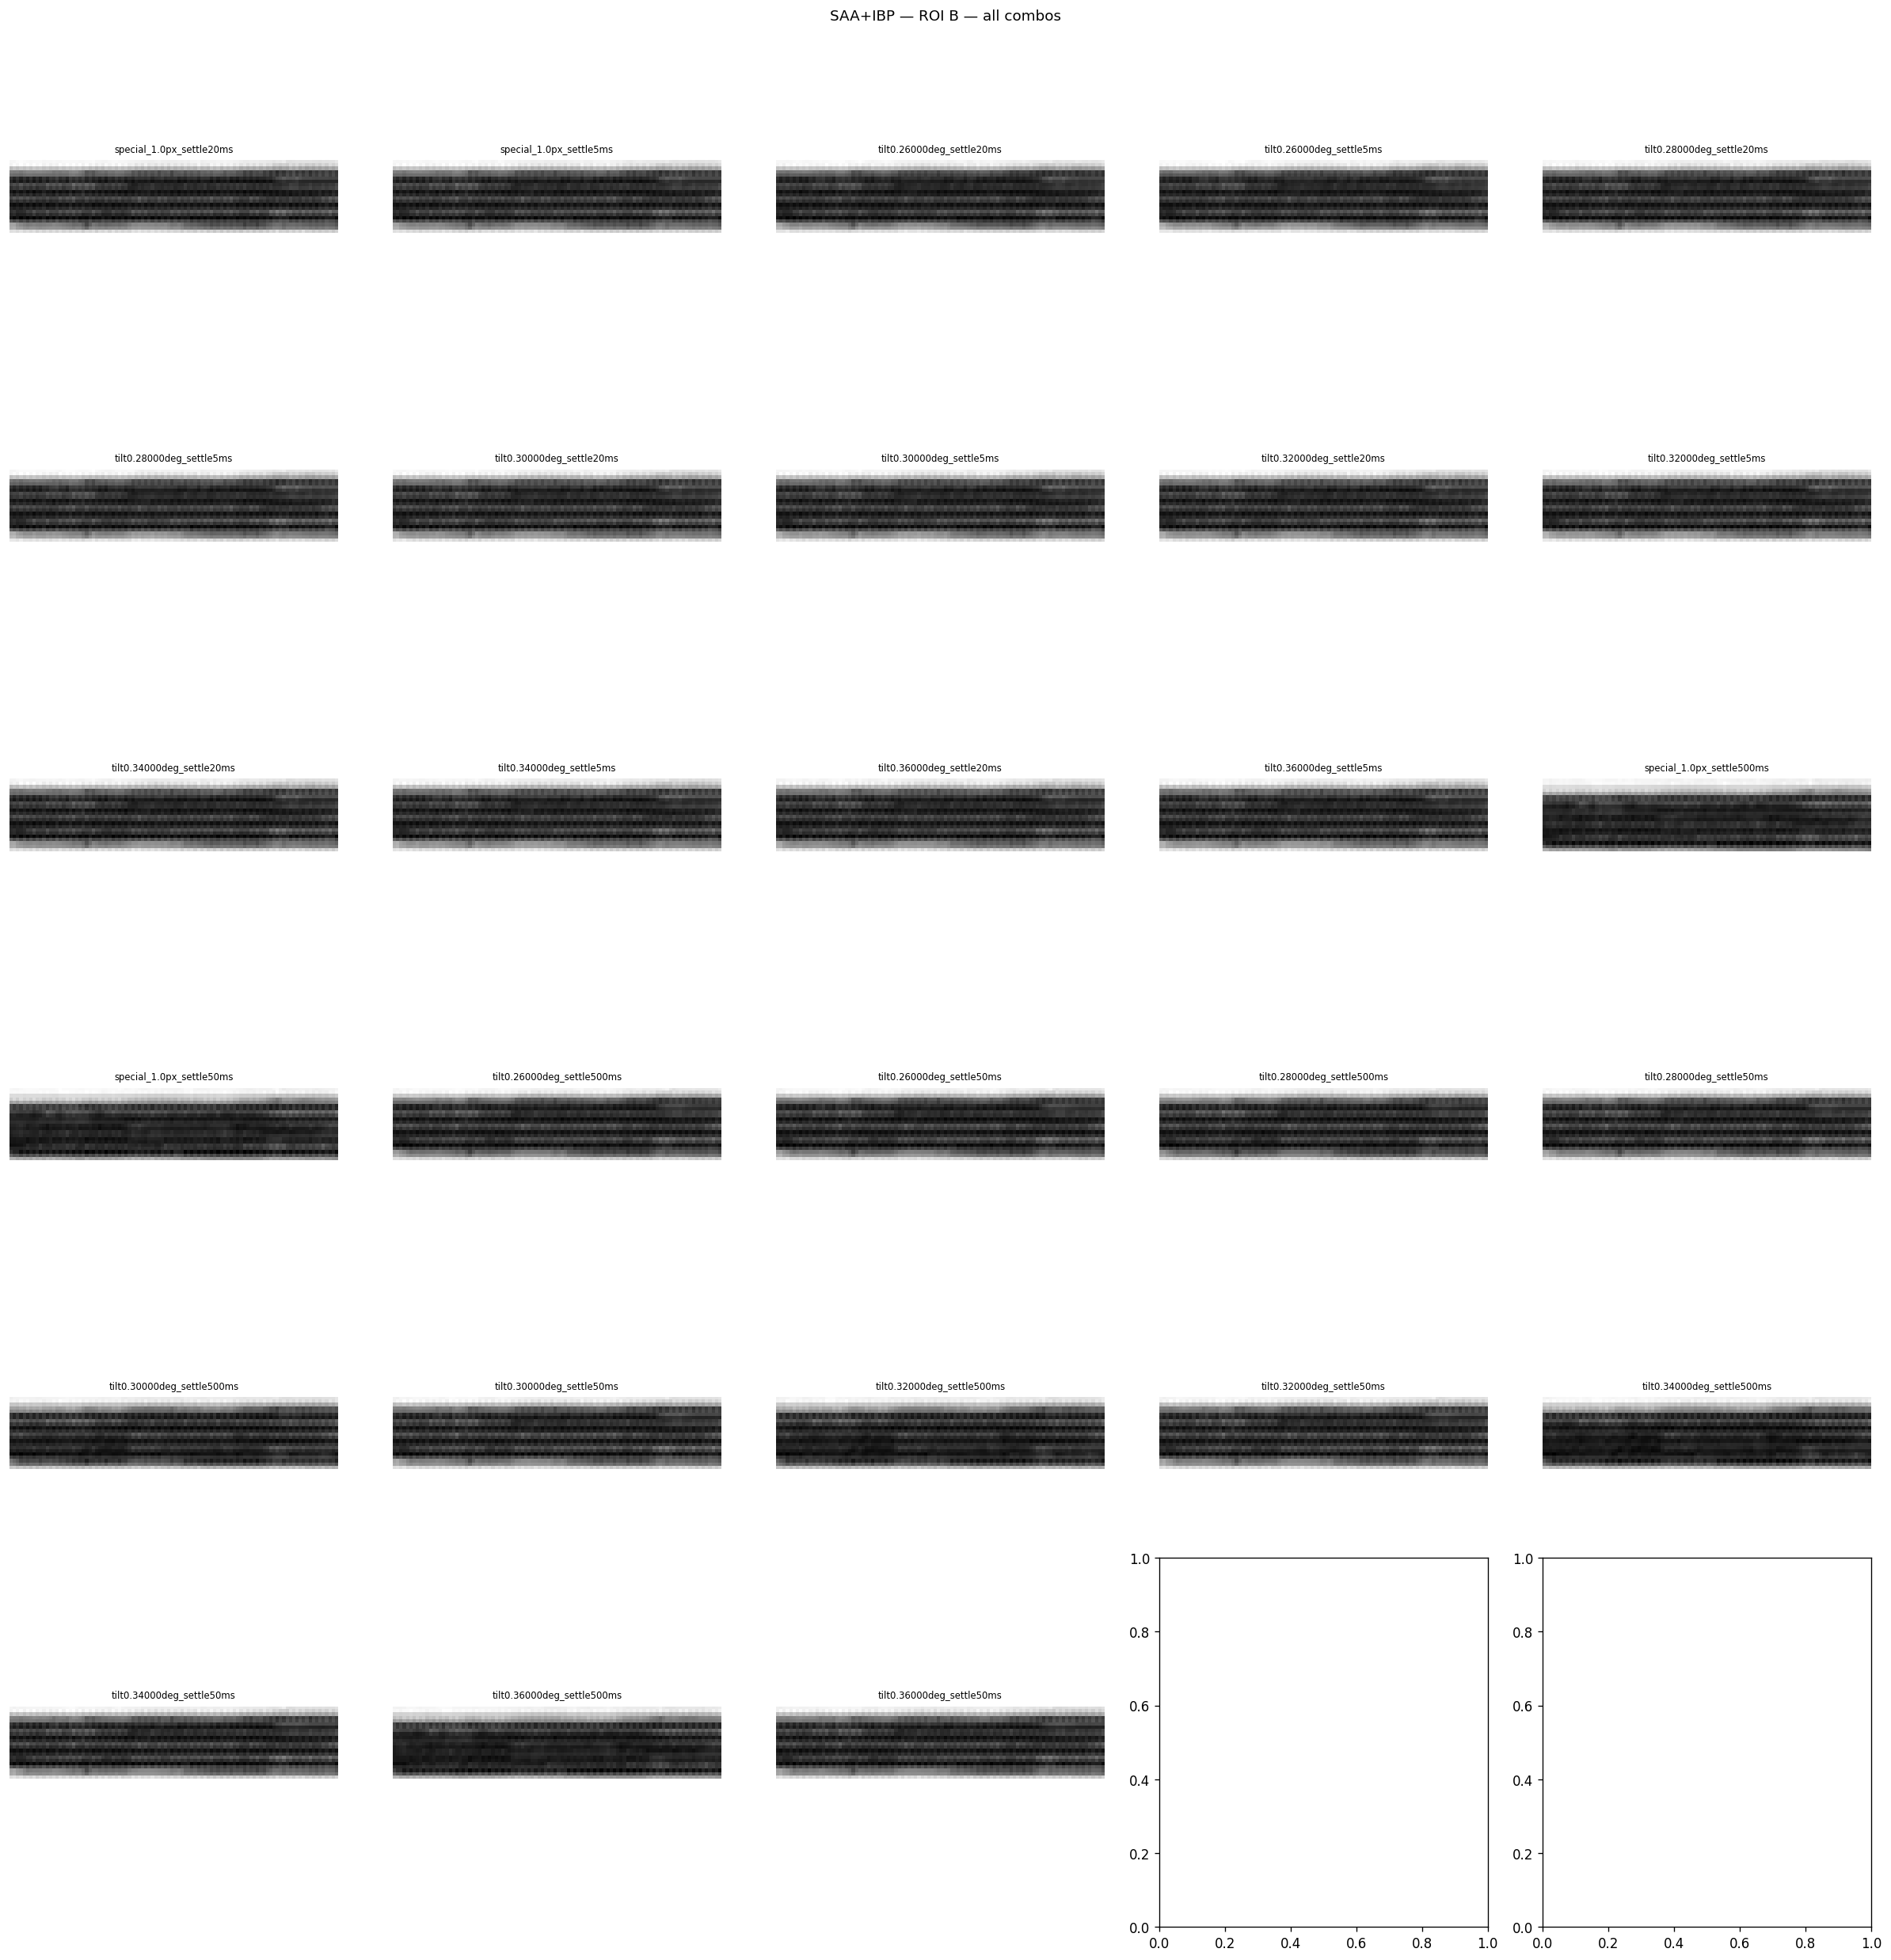

In [26]:
METHOD_TO_COMPARE = 'SAA+IBP'   # or 'SAA', 'Native-2x'
ROI_TO_COMPARE    = 'ROI B'
r0, r1, c0, c1    = ROIS[ROI_TO_COMPARE]

all_combos = []
for session in ['20260327_125058', '20260327_125302']:
    results_dir = os.path.join(BASE, session, 'results')
    if not os.path.isdir(results_dir):
        continue
    for combo in sorted(os.listdir(results_dir)):
        fname = os.path.join(results_dir, combo,
                             f"{METHOD_TO_COMPARE.replace('+','_')}.png")
        if os.path.exists(fname):
            all_combos.append((f'{session}/{combo}', fname))

print(f'Found {len(all_combos)} completed combos for {METHOD_TO_COMPARE}')

n = len(all_combos)
if n == 0:
    print('Run sweep_sr_mar27.py first.')
else:
    cols = min(n, 5)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
    axes = np.array(axes).flat
    for ax, (label, fname) in zip(axes, all_combos):
        img = np.array(Image.open(fname), dtype=np.float64)
        ax.imshow(img[r0:r1, c0:c1], cmap='gray', interpolation='nearest')
        ax.set_title(label.split('/')[-1], fontsize=7)
        ax.axis('off')
    for ax in list(axes)[n:]:
        ax.axis('off')
    plt.suptitle(f'{METHOD_TO_COMPARE} — {ROI_TO_COMPARE} — all combos', fontsize=11)
    plt.tight_layout()
    plt.show()

## 8. MTF from slanted edges (ROI A)

The thick dark line has two slanted edges — a **falling** edge (bright→dark on the left side) and a **rising** edge (dark→bright on the right side). Each is a genuine step transition limited only by the optics, making them ideal ISO 12233-style slanted-edge MTF targets.

**Algorithm per edge:**
1. Auto-detect left/right edge column from the column-mean gradient
2. Crop ±`EDGE_MARGIN` pixels around each edge
3. Find edge position per row via argmin/argmax of the row gradient → robust linear fit → oversampled ESF
4. Normalise ESF to [0, 1], differentiate → LSF
5. FFT → MTF, normalise by DC so MTF(0) = 1
6. Average left and right MTFs

The first cell below verifies the auto-detected edge positions. Adjust `EDGE_MARGIN` if the crops look wrong.

In [ ]:
PITCH_HR_UM     = 3.45
PX_TO_CYMM      = 1.0 / (PITCH_HR_UM * 1e-3)
LR_NYQUIST_CYMM = 0.25 * PX_TO_CYMM   #  72.5 cy/mm
HR_NYQUIST_CYMM = 0.50 * PX_TO_CYMM   # 144.9 cy/mm

METHOD_COLORS = {'Native-2x': '#4477AA', 'SAA': '#228833', 'SAA+IBP': '#CC3311'}

BRIGHT_MARGIN   = 20   # pixels into the flat bright field — generous is fine
MAX_DARK_MARGIN = 10   # hard cap; auto-reduced to stay within dark line below


# ── Functions ─────────────────────────────────────────────────────────────────

def find_edge_lines(crop):
    """
    Find left (bright→dark) and right (dark→bright) edge line equations
    for a thick dark diagonal line in the crop.
    Returns p_left, p_right — each is (slope, intercept) for col = p[0]*row + p[1]
    """
    H, W  = crop.shape
    rows  = np.arange(H, dtype=float)
    left_cols  = np.zeros(H)
    right_cols = np.zeros(H)

    for r in range(H):
        g = gaussian_filter1d(np.gradient(crop[r].astype(float)), sigma=1.5)
        left_cols[r]  = np.argmin(g)
        right_cols[r] = np.argmax(g)

    def robust_fit(ys):
        p = np.polyfit(rows, ys, 1)
        for _ in range(3):
            res  = ys - np.polyval(p, rows)
            keep = np.abs(res) < 5.0
            if keep.sum() > 10:
                p = np.polyfit(rows[keep], ys[keep], 1)
        return p

    return robust_fit(left_cols), robust_fit(right_cols)


def slanted_edge_mtf_diag(img_roi, edge_p, oversample=8, rising=True,
                           bright_margin=20, dark_margin=8):
    """
    ISO 12233-style slanted-edge MTF with ASYMMETRIC margins.

    bright_margin : pixels into the flat bright field (generous is fine — no contamination risk)
    dark_margin   : pixels into the dark line  (must be < half the line width!)

    For a rising edge (dark→bright):  dark side = negative hdist, bright side = positive
    For a falling edge (bright→dark): bright side = negative hdist, dark side = positive

    Normalises ESF using flat-plateau medians (robust against tail contamination).
    Gaussian-smooths the ESF (σ=0.5 HR px) before differentiating, then
    normalises MTF by its DC component so MTF(0) = 1 always.
    """
    H, W  = img_roi.shape
    rows  = np.arange(H)
    cols  = np.arange(W)

    edge_col = np.polyval(edge_p, rows)[:, None]
    R, C     = np.meshgrid(rows, cols, indexing='ij')
    hdist    = (C - edge_col).astype(float)

    if rising:
        # dark side: negative hdist; bright side: positive hdist
        mask = (hdist >= -dark_margin) & (hdist <= bright_margin)
    else:
        # bright side: negative hdist; dark side: positive hdist
        mask = (hdist >= -bright_margin) & (hdist <= dark_margin)

    dist_m = hdist[mask]
    vals_m = img_roi[mask].astype(float)

    # Bin into oversampled ESF
    bw   = 1.0 / oversample
    bins = np.arange(dist_m.min(), dist_m.max() + bw, bw)
    idx  = np.clip(np.digitize(dist_m, bins) - 1, 0, len(bins) - 2)

    esf_s = np.bincount(idx, weights=vals_m, minlength=len(bins) - 1)
    esf_n = np.bincount(idx,                minlength=len(bins) - 1)
    valid = esf_n > 0
    esf_d = (bins[:-1] + bw / 2)[valid]
    esf_v = esf_s[valid] / esf_n[valid]

    # ── Normalise using flat-region medians ───────────────────────────────────
    if rising:
        bright_flat = esf_d >  (bright_margin * 0.5)
        dark_flat   = esf_d < -(dark_margin   * 0.5)
    else:
        bright_flat = esf_d < -(bright_margin * 0.5)
        dark_flat   = esf_d >  (dark_margin   * 0.5)

    bright_level = np.median(esf_v[bright_flat]) if bright_flat.any() else esf_v.max()
    dark_level   = np.median(esf_v[dark_flat])   if dark_flat.any()   else esf_v.min()

    esf_norm = (esf_v - dark_level) / (bright_level - dark_level + 1e-10)
    esf_norm = np.clip(esf_norm, -0.05, 1.05)

    if not rising:
        esf_norm = 1.0 - esf_norm   # display convention: always show 0→1

    # ── LSF → windowed FFT → MTF ──────────────────────────────────────────────
    # Smooth ESF slightly before differentiating (ISO 12233 practice).
    # sigma = oversample/2 bins = 0.5 HR px: mild, preserves MTF to HR Nyquist.
    esf_smooth = gaussian_filter1d(esf_norm, sigma=oversample / 2)
    lsf = np.gradient(esf_smooth, bw)

    # rfft[0] = sum(array) — no bw factor — so normalise by mtf[0] directly.
    # MTF(0) = 1 as long as esf_smooth spans [0, 1].
    mtf       = np.abs(np.fft.rfft(lsf))
    freq_cypx = np.fft.rfftfreq(len(lsf), d=bw)
    freq_cymm = freq_cypx * PX_TO_CYMM

    if mtf[0] > 0.01:
        mtf /= mtf[0]

    return freq_cymm, mtf, esf_d, esf_norm


def find_mtf50(freq, mtf):
    for i in range(1, len(mtf)):
        if mtf[i] <= 0.5 <= mtf[i - 1]:
            t = (0.5 - mtf[i - 1]) / (mtf[i] - mtf[i - 1])
            return freq[i - 1] + t * (freq[i] - freq[i - 1])
    return None


# ── Verification ──────────────────────────────────────────────────────────────

r0, r1, c0, c1 = ROIS['ROI A']
ref_crop        = images['Native-2x'][r0:r1, c0:c1]
H_c, W_c        = ref_crop.shape

p_left, p_right = find_edge_lines(ref_crop)
rows_ref        = np.arange(H_c)
left_line       = np.polyval(p_left,  rows_ref)
right_line      = np.polyval(p_right, rows_ref)

slope_deg  = np.degrees(np.arctan(p_left[0]))
full_width = (right_line - left_line).mean()
half_width = full_width / 2.0

# Auto-cap dark margin: stay within 70% of half-width from each edge
dark_margin = max(4, min(MAX_DARK_MARGIN, half_width * 0.7))

print(f'ROI A: {H_c} rows x {W_c} cols')
print(f'Line slope:  {p_left[0]:.3f} col/row  ({slope_deg:.1f} deg from vertical)')
print(f'Line width:  {full_width:.1f} HR px  =  {full_width*PITCH_HR_UM:.0f} um')
print(f'Half-width:  {half_width:.1f} px  ->  dark_margin capped at {dark_margin:.1f} px')
print(f'Left edge:  col = {p_left[0]:.3f}*row + {p_left[1]:.1f}')
print(f'Right edge: col = {p_right[0]:.3f}*row + {p_right[1]:.1f}')

_, _, esf_d_l, esf_v_l = slanted_edge_mtf_diag(ref_crop, p_left,  rising=False,
                                                  bright_margin=BRIGHT_MARGIN, dark_margin=dark_margin)
_, _, esf_d_r, esf_v_r = slanted_edge_mtf_diag(ref_crop, p_right, rising=True,
                                                  bright_margin=BRIGHT_MARGIN, dark_margin=dark_margin)

# Pixel band visualisation (asymmetric)
band_viz = np.zeros((H_c, W_c, 3), dtype=np.uint8)
grey     = np.clip(ref_crop, 0, 255).astype(np.uint8)
band_viz[:, :, 0] = grey;  band_viz[:, :, 1] = grey;  band_viz[:, :, 2] = grey

cols_ref = np.arange(W_c)
R_g, C_g = np.meshgrid(rows_ref, cols_ref, indexing='ij')
hdist_l  = C_g - np.polyval(p_left,  rows_ref)[:, None]
hdist_r  = C_g - np.polyval(p_right, rows_ref)[:, None]

left_band  = (hdist_l >= -BRIGHT_MARGIN) & (hdist_l <= dark_margin)
right_band = (hdist_r >= -dark_margin)   & (hdist_r <= BRIGHT_MARGIN)

band_viz[left_band,  2] = np.clip(band_viz[left_band,  2].astype(int) + 80, 0, 255)
band_viz[left_band,  1] = np.clip(band_viz[left_band,  1].astype(int) + 40, 0, 255)
band_viz[right_band, 0] = np.clip(band_viz[right_band, 0].astype(int) + 80, 0, 255)
band_viz[right_band, 1] = np.clip(band_viz[right_band, 1].astype(int) + 80, 0, 255)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# [0,0] ROI with fitted lines + band limits
axes[0,0].imshow(ref_crop, cmap='gray', aspect='auto', interpolation='nearest')
axes[0,0].plot(left_line,  rows_ref, color='cyan',   lw=2, label='Left edge')
axes[0,0].plot(right_line, rows_ref, color='yellow', lw=2, label='Right edge')
axes[0,0].plot(left_line  - BRIGHT_MARGIN, rows_ref, color='cyan',   lw=1, ls=':', alpha=0.6)
axes[0,0].plot(left_line  + dark_margin,   rows_ref, color='cyan',   lw=1.5, ls='--')
axes[0,0].plot(right_line - dark_margin,   rows_ref, color='yellow', lw=1.5, ls='--')
axes[0,0].plot(right_line + BRIGHT_MARGIN, rows_ref, color='yellow', lw=1, ls=':', alpha=0.6)
axes[0,0].set_title(f'ROI A: edges + band limits\n'
                    f'Line width {full_width:.0f} px, dark_margin {dark_margin:.1f} px\n'
                    f'(solid=edge, dashed=dark limit, dotted=bright limit)', fontsize=8)
axes[0,0].legend(fontsize=8);  axes[0,0].axis('off')

# [0,1] Pixel band
axes[0,1].imshow(band_viz, aspect='auto', interpolation='nearest')
axes[0,1].set_title('Pixel bands (cyan=left, yellow=right)\nasymmetric: wide on bright side, narrow on dark', fontsize=9)
axes[0,1].axis('off')

# [0,2] Per-row scatter vs fit
row_arr = np.arange(H_c)
per_row_left  = np.array([np.argmin(gaussian_filter1d(np.gradient(ref_crop[r].astype(float)), sigma=1.5)) for r in row_arr])
per_row_right = np.array([np.argmax(gaussian_filter1d(np.gradient(ref_crop[r].astype(float)), sigma=1.5)) for r in row_arr])
axes[0,2].scatter(per_row_left,  row_arr, s=2, c='cyan',   label='Left (argmin grad)')
axes[0,2].scatter(per_row_right, row_arr, s=2, c='orange', label='Right (argmax grad)')
axes[0,2].plot(np.polyval(p_left,  row_arr), row_arr, 'c-',  lw=1.5, label='Left fit')
axes[0,2].plot(np.polyval(p_right, row_arr), row_arr, 'y-',  lw=1.5, label='Right fit')
axes[0,2].invert_yaxis()
axes[0,2].set_xlabel('Column', fontsize=9);  axes[0,2].set_ylabel('Row', fontsize=9)
axes[0,2].set_title('Per-row edge detection vs fit', fontsize=9)
axes[0,2].legend(fontsize=7);  axes[0,2].grid(True, alpha=0.3)

# [1,0] Left ESF
axes[1,0].plot(esf_d_l, esf_v_l, color='cyan', lw=1.5)
axes[1,0].axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
axes[1,0].axhline(0, color='gray', ls=':', lw=0.8, alpha=0.4)
axes[1,0].axhline(1, color='gray', ls=':', lw=0.8, alpha=0.4)
axes[1,0].set_xlabel('Horiz. distance from left edge (HR px)', fontsize=9)
axes[1,0].set_ylabel('Normalised intensity', fontsize=9)
axes[1,0].set_title('Left edge ESF  (bright->dark, shown as 0->1)', fontsize=9)
axes[1,0].set_ylim(-0.1, 1.1);  axes[1,0].grid(True, alpha=0.3)

# [1,1] Right ESF
axes[1,1].plot(esf_d_r, esf_v_r, color='orange', lw=1.5)
axes[1,1].axvline(0, color='gray', ls='--', lw=0.8, alpha=0.5)
axes[1,1].axhline(0, color='gray', ls=':', lw=0.8, alpha=0.4)
axes[1,1].axhline(1, color='gray', ls=':', lw=0.8, alpha=0.4)
axes[1,1].set_xlabel('Horiz. distance from right edge (HR px)', fontsize=9)
axes[1,1].set_ylabel('Normalised intensity', fontsize=9)
axes[1,1].set_title('Right edge ESF  (dark->bright, shown as 0->1)', fontsize=9)
axes[1,1].set_ylim(-0.1, 1.1);  axes[1,1].grid(True, alpha=0.3)

# [1,2] MTF preview
f_l, mtf_l, _, _ = slanted_edge_mtf_diag(ref_crop, p_left,  rising=False,
                                           bright_margin=BRIGHT_MARGIN, dark_margin=dark_margin)
f_r, mtf_r, _, _ = slanted_edge_mtf_diag(ref_crop, p_right, rising=True,
                                           bright_margin=BRIGHT_MARGIN, dark_margin=dark_margin)
mtf_r_i = np.interp(f_l, f_r, mtf_r, right=0.0)
mtf_avg = (mtf_l + mtf_r_i) / 2.0
axes[1,2].plot(f_l, mtf_l,  color='cyan',  lw=1.2, ls='--', alpha=0.7, label='Left edge')
axes[1,2].plot(f_r, mtf_r,  color='orange',lw=1.2, ls='--', alpha=0.7, label='Right edge')
axes[1,2].plot(f_l, mtf_avg,color='black', lw=2.0,           label='Average')
axes[1,2].axvline(LR_NYQUIST_CYMM, color='dimgray', ls='--', lw=1, alpha=0.7)
axes[1,2].axvline(HR_NYQUIST_CYMM, color='black',   ls='--', lw=1, alpha=0.7)
axes[1,2].axhline(0.5, color='gray', ls=':', lw=1, alpha=0.5)
axes[1,2].set_xlim(0, HR_NYQUIST_CYMM * 1.15);  axes[1,2].set_ylim(0, 1.1)
axes[1,2].set_xlabel('Spatial frequency (cy/mm)', fontsize=9)
axes[1,2].set_ylabel('MTF', fontsize=9)
axes[1,2].set_title('MTF preview -- Native-2x', fontsize=9)
axes[1,2].legend(fontsize=8);  axes[1,2].grid(True, alpha=0.3)

m50 = find_mtf50(f_l, mtf_avg)
if m50:
    print(f'\nNative-2x MTF50 preview: {m50:.1f} cy/mm')

plt.suptitle('Edge detection verification -- ROI A', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# ── MTF comparison — all SR methods ──────────────────────────────────────────

r0, r1, c0, c1 = ROIS['ROI A']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

header = f"{'Method':<14}  {'MTF50 left':>12}  {'MTF50 right':>12}  {'MTF50 avg':>12}  {'vs Native-2x':>13}"
print(header)
print(f"{'':14}  {'(cy/mm)':>12}  {'(cy/mm)':>12}  {'(cy/mm)':>12}")
print('─' * 70)

mtf50_avgs = {}
for name, img in images.items():
    if name == 'LR red':
        continue
    crop = img[r0:r1, c0:c1]
    pl, pr = find_edge_lines(crop)

    # Use the same dark_margin determined for Native-2x (line geometry is fixed)
    f_l, mtf_l, _, _ = slanted_edge_mtf_diag(crop, pl, rising=False,
                                               bright_margin=BRIGHT_MARGIN, dark_margin=dark_margin)
    f_r, mtf_r, _, _ = slanted_edge_mtf_diag(crop, pr, rising=True,
                                               bright_margin=BRIGHT_MARGIN, dark_margin=dark_margin)

    mtf_r_i  = np.interp(f_l, f_r, mtf_r, right=0.0)
    mtf_avg  = (mtf_l + mtf_r_i) / 2.0

    m50_l   = find_mtf50(f_l, mtf_l)
    m50_r   = find_mtf50(f_r, mtf_r)
    m50_avg = find_mtf50(f_l, mtf_avg)
    mtf50_avgs[name] = m50_avg

    color = METHOD_COLORS.get(name, 'gray')
    axes[0].plot(f_l, mtf_avg, lw=2.0,  label=name, color=color)
    axes[1].plot(f_l, mtf_l,  lw=1.0, ls='--', color=color, alpha=0.5)
    axes[1].plot(f_r, mtf_r,  lw=1.0, ls=':',  color=color, alpha=0.5)
    axes[1].plot(f_l, mtf_avg, lw=1.8, label=name, color=color)

    def fmt(v): return f'{v:.1f}' if v else 'N/A'
    native50 = mtf50_avgs.get('Native-2x')
    imp = f'+{(m50_avg/native50 - 1)*100:.1f}%' if (m50_avg and native50 and name != 'Native-2x') else '—'
    print(f'{name:<14}  {fmt(m50_l):>12}  {fmt(m50_r):>12}  {fmt(m50_avg):>12}  {imp:>13}')

for ax in axes:
    ax.axvline(LR_NYQUIST_CYMM, color='dimgray', ls='--', lw=1.2, alpha=0.7)
    ax.axvline(HR_NYQUIST_CYMM, color='black',   ls='--', lw=1.2, alpha=0.7)
    ax.axhline(0.50,            color='gray',    ls=':',  lw=1.0, alpha=0.5)
    ax.set_xlim(0, HR_NYQUIST_CYMM * 1.15);  ax.set_ylim(0, 1.1)
    ax.set_xlabel('Spatial frequency (cycles / mm)', fontsize=10)
    ax.set_ylabel('MTF', fontsize=10)
    ax.legend(fontsize=9);  ax.grid(True, alpha=0.3)

axes[0].text(LR_NYQUIST_CYMM + 1, 0.03, f'LR Nyquist\n({LR_NYQUIST_CYMM:.0f} cy/mm)', fontsize=8, color='dimgray', va='bottom')
axes[0].text(HR_NYQUIST_CYMM + 1, 0.03, f'HR Nyquist\n({HR_NYQUIST_CYMM:.0f} cy/mm)', fontsize=8, color='black',   va='bottom')
axes[0].text(2, 0.52, 'MTF 50%', fontsize=8, color='gray')
axes[0].set_title('MTF — averaged left + right edges', fontsize=11)
axes[1].set_title('MTF — individual edges (-- left, ... right, solid avg)', fontsize=10)

plt.suptitle('Slanted-edge MTF — ROI A', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Gradient sharpness and power spectral density

Two simpler metrics that work on **any ROI** (not just a slanted line):

- **RMS gradient** — mean magnitude of the image gradient. Sharper images have stronger gradients at edges and fine detail.
- **High-frequency power ratio** — fraction of PSD energy above the LR Nyquist (0.25 cy/px). A higher ratio means more true high-frequency content, which SR should increase.

In [ ]:
def rms_gradient(img_crop):
    """RMS magnitude of the Sobel gradient."""
    gy = img_crop[1:, :] - img_crop[:-1, :]
    gx = img_crop[:, 1:] - img_crop[:, :-1]
    h = min(gy.shape[0], gx.shape[0])
    w = min(gy.shape[1], gx.shape[1])
    mag = np.sqrt(gy[:h, :w]**2 + gx[:h, :w]**2)
    return mag.mean()


def hf_power_ratio(img_crop, lr_nyquist=0.25):
    """
    Fraction of 2-D PSD energy at spatial frequencies > lr_nyquist cy/px.
    lr_nyquist = 0.25 cy/HR px is the red-channel LR Nyquist.
    """
    H, W   = img_crop.shape
    psd    = np.abs(np.fft.fftshift(np.fft.fft2(img_crop)))**2
    fy     = np.fft.fftshift(np.fft.fftfreq(H))
    fx     = np.fft.fftshift(np.fft.fftfreq(W))
    FX, FY = np.meshgrid(fx, fy)
    r      = np.sqrt(FX**2 + FY**2)
    return psd[r > lr_nyquist].sum() / psd.sum()


# ── HF power ratio — ROI B only ───────────────────────────────────────────────

r0, r1, c0, c1 = ROIS['ROI B']
method_names   = [n for n in images if n != 'LR red']
hf_vals        = {name: hf_power_ratio(images[name][r0:r1, c0:c1]) for name in method_names}
baseline_hf    = hf_vals['Native-2x']

print('HF power ratio > LR Nyquist (0.25 cy/px) — ROI B')
print('Higher = more energy above the LR sampling limit = more SR content')
print()
for name, val in hf_vals.items():
    change = f'  (+{(val/baseline_hf - 1)*100:.1f}% vs Native-2x)' if name != 'Native-2x' else ''
    print(f'  {name:<14}  {val:.4f}{change}')

# ── Bar chart ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(6, 4))

colors = [METHOD_COLORS.get(n, 'gray') for n in method_names]
bars   = ax.bar(method_names, [hf_vals[n] for n in method_names],
                color=colors, alpha=0.85, width=0.5)

# Annotate each bar with the % change vs Native-2x
for bar, name in zip(bars, method_names):
    val = hf_vals[name]
    label = f'{val:.4f}'
    if name != 'Native-2x':
        label += f'\n(+{(val/baseline_hf - 1)*100:.1f}%)'
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0002,
            label, ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Fraction of PSD above LR Nyquist', fontsize=10)
ax.set_title('High-frequency power ratio — ROI B\n'
             '(energy > 0.25 cy/px, i.e. above the LR sampling limit)', fontsize=10)
ax.set_ylim(0, max(hf_vals.values()) * 1.18)
ax.tick_params(axis='x', labelsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()